In [1]:
import sys
sys.path.append("/Users/emilieyu/endotehelial-masboss")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import copy

from abm.rho_lookup_table import RhoLookupTable
from abm.endothelial_cell import EndothelialCell
from abm.stress_fibre import StressFibre
from abm.flow_field import FlowField
from src.config import load_abm_sim_cfg, load_bm_sweep_cfg
from src.paths import BM_RESULTS_DIR

from abm.scripts.run_abm_sim import run_abm_sim, run_abm_sim_single, get_perb_cfg, plot_cell

sim_cfg = load_abm_sim_cfg()
lut = RhoLookupTable(sim_cfg, BM_RESULTS_DIR)
perbs = sim_cfg['perturbations']


>>> DEBUG: Successfully loaded recruitment parameter sweep data.
>>> DEBUG: Successfully built interpolators
LUT ready | rest: RhoA=0.395 RhoC=0.406


In [2]:
dsp_cfg = get_perb_cfg(sim_cfg, perbs['DSP_KO'])
tjp1_cfg = get_perb_cfg(sim_cfg, perbs['TJP1_KO'])
jcad_cfg = get_perb_cfg(sim_cfg, perbs['JCAD_KO'])
tjp1_jcad_cfg = get_perb_cfg(sim_cfg, perbs['TJP1_JCAD_DKO'])
dsp_jcad_cfg = get_perb_cfg(sim_cfg, perbs['DSP_JCAD_DKO'])

>>> INFO: Initiated flow field with magnitude 10.0 and unit direction [1. 0.]
{'extension': np.float64(0.0), 'stiffness': 0.7, 'tension': np.float64(0.0), 'activation': 0.999, 'axis': array([ 1., -0.])}


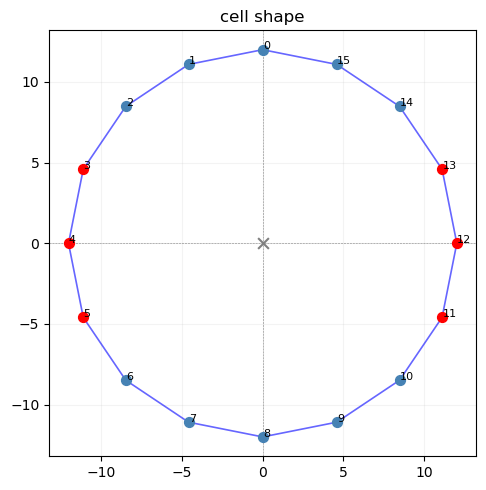

In [9]:
res_wt = run_abm_sim_single(sim_cfg, lut, 1, 'WT', True)

In [4]:
res_wt['cell_final'], res_wt['springs_final']

({'cell_id': 0,
  'ar': np.float64(2.457),
  'orientation': np.float64(0.0),
  'area_ratio': np.float64(1.0089),
  'mean_rhoa_polar': 0.575,
  'mean_rhoa_lateral': 0.529,
  'mean_rhoc': 0.537,
  'a_sf': 0.866,
  'sf_tension': np.float64(13.963),
  'k_polar': np.float64(1.567),
  'k_lateral': np.float64(1.529),
  'tensile_polar': 23.232,
  'f_total': 10.0},
     id  extension  stiffness  tension  activation
 0    0     1.5661     1.5288   3.3198       0.871
 1    1     1.5119     1.5453   3.2900       0.868
 2    2     0.8026     1.5709   2.2584       0.864
 3    3     0.2209     1.5849   1.3720       0.862
 4    4     0.2209     1.5849   1.3720       0.862
 5    5     0.8026     1.5709   2.2584       0.864
 6    6     1.5119     1.5453   3.2900       0.868
 7    7     1.5661     1.5288   3.3198       0.871
 8    8     1.5661     1.5288   3.3198       0.871
 9    9     1.5119     1.5453   3.2900       0.868
 10  10     0.8026     1.5709   2.2584       0.864
 11  11     0.2209     1.5849

>>> INFO: Initiated flow field with magnitude 10.0 and unit direction [1. 0.]
{'extension': np.float64(17.7145), 'stiffness': 0.7, 'tension': np.float64(14.365), 'activation': 0.883, 'axis': array([ 1., -0.])}


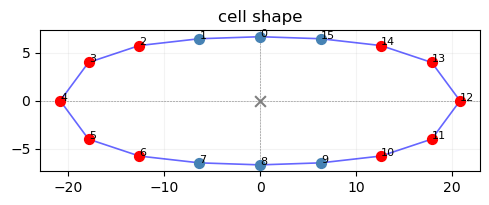

In [5]:
res_jcad = run_abm_sim_single(jcad_cfg, lut, 3000, 'JCAD', True)

In [6]:
res_jcad['cell_final'], res_jcad['springs_final']

({'cell_id': 0,
  'ar': np.float64(2.549),
  'orientation': np.float64(0.0),
  'area_ratio': np.float64(1.0128),
  'mean_rhoa_polar': 0.501,
  'mean_rhoa_lateral': 0.47,
  'mean_rhoc': 0.468,
  'a_sf': 0.883,
  'sf_tension': np.float64(14.365),
  'k_polar': np.float64(1.496),
  'k_lateral': np.float64(1.471),
  'tensile_polar': 23.359,
  'f_total': 10.0},
     id  extension  stiffness  tension  activation
 0    0     1.6614     1.4705   3.2734       0.879
 1    1     1.6195     1.4818   3.2478       0.878
 2    2     0.9009     1.4986   2.2256       0.875
 3    3     0.3039     1.5073   1.3477       0.874
 4    4     0.3039     1.5073   1.3477       0.874
 5    5     0.9009     1.4986   2.2256       0.875
 6    6     1.6195     1.4818   3.2478       0.878
 7    7     1.6614     1.4705   3.2734       0.879
 8    8     1.6614     1.4705   3.2734       0.879
 9    9     1.6195     1.4818   3.2478       0.878
 10  10     0.9009     1.4986   2.2256       0.875
 11  11     0.3039     1.5073 

>>> INFO: Initiated flow field with magnitude 10.0 and unit direction [1. 0.]
{'extension': np.float64(21.7964), 'stiffness': 0.7, 'tension': np.float64(18.1579), 'activation': 0.827, 'axis': array([1., 0.])}


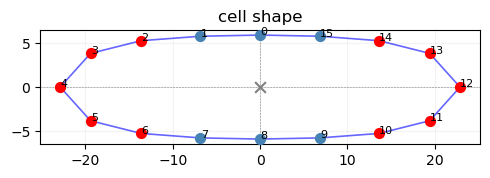

In [7]:
res_dsp = run_abm_sim_single(dsp_cfg, lut, 2000, 'DSP', True)

In [ ]:
res_dsp['cell_final'], res_dsp['springs_final']

In [ ]:
res_dsp_jcad = run_abm_sim_single(dsp_jcad_cfg, lut, 2000, 'DSP_JCAD', True)

In [ ]:
res_dsp_jcad['cell_final'], res_dsp_jcad['springs_final']

In [ ]:
res_tjp1 = run_abm_sim_single(tjp1_cfg, lut, 3000, 'TJP1', True)

In [ ]:
res_tjp1['cell_final'], res_tjp1['springs_final']

In [ ]:
res_tjp1_jcad = run_abm_sim_single(tjp1_jcad_cfg, lut, 2000, 'TJP1_JCAD', True)

In [ ]:
res_tjp1_jcad['cell_final'], res_tjp1_jcad['springs_final']

In [8]:
ts_df, ss_df = run_abm_sim(sim_cfg, lut, 3000)

>>> INFO: Running abm simulation perturbation: WT (3000 steps).
>>> INFO: Initiated flow field with magnitude 10.0 and unit direction [1. 0.]
{'extension': np.float64(16.7269), 'stiffness': 0.7, 'tension': np.float64(13.9629), 'activation': 0.866, 'axis': array([ 1., -0.])}
WT                  2.457      0.0°  0.866 
>>> INFO: Running abm simulation perturbation: DSP_KO (3000 steps).
>>> INFO: Initiated flow field with magnitude 10.0 and unit direction [1. 0.]
{'extension': np.float64(21.7864), 'stiffness': 0.7, 'tension': np.float64(18.1545), 'activation': 0.827, 'axis': array([ 1., -0.])}
DSP_KO              3.036      0.0°  0.827 
>>> INFO: Running abm simulation perturbation: TJP1_KO (3000 steps).
>>> INFO: Initiated flow field with magnitude 10.0 and unit direction [1. 0.]
{'extension': np.float64(12.409), 'stiffness': 0.7, 'tension': np.float64(9.7165), 'activation': 0.939, 'axis': array([ 1., -0.])}
TJP1_KO             1.957    180.0°  0.939 
>>> INFO: Running abm simulation per

In [ ]:
ss_df